# Formula Sheet

In [1]:
import math
import random
import statistics
import matplotlib.pyplot as plt

<b>Finance/statistics formulas</b>

Consider a three-year investment horizon where you invest $100 today:

$$
\begin{array}{ll}
\text{3-year cumulative gross return:} & ((1+r_1)*(1+r_2)*(1+r_3)) \\
\text{3-year cumulative net return:} & ((1+r_1)*(1+r_2)*(1+r_3)) - 1 \\
\text{3-year geometric average return:}   & ((1+r_1)*(1+r_2)*(1+r_3))^{(1/3)} - 1 \\
\text{3-year arithmetic average return:}  & (r_1 + r_2 + r_3) / 3 \\
\text{$FV_3$} & 100 * (1+r_1)(1+r_2)(1+r_3) \\
\end{array}
$$

<b>Sharpe Ratio</b>:  $\frac{\text{Expected return - risk-free rate}}{\text{Std dev returns}}$

In [2]:
# Simulating compound returns

nret = [ max(random.gauss(0.1,0.2),-1)   for num in range(3) ]
gret = [ 1 + r   for r in nret ]

cgret1 =   math.prod(gret)                                             # single estimate
cgret2 = [ math.prod(gret[0:num]) for num in range(1,len(gret)+1) ]    # year by year estimates

print(cgret1, cgret2)

2.217651719400662 [1.4563955072566095, 1.8941075692697291, 2.217651719400662]


<b>Expected Utility and Certainty Equivalent</b>

1. Simulate outcome (typically a future value)
2. Convert each outcome into its corresponding utility
3. Average across utilities to calculate expected utility
4. Use inverse of utility function to convert back into certainty equivalent
   - When we use math.log() for utility, CE = math.exp(EU)
   - When we use math.sqrt() for utility, CE = EU**2
   - If utility were based on 1/3rd root, CE = EU**3

<b>Strings, lists, for loops</b>


In [3]:
# Converting strings into floats
l_text = [['ETF1','0.1243','0.2312'],['ETF2','0.1321','0.2543']]
l_nums = [ [r[0], float(r[1]), float(r[2])] for r in l_text ]
l_nums

[['ETF1', 0.1243, 0.2312], ['ETF2', 0.1321, 0.2543]]

In [4]:
l = ['a', 'a', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']

print(l[0])     # element 0, returned as string
print(l[3:5])   # elements 3 and 4, returned as list

a
['b', 'c']


In [5]:
l.count('a')    # counts number of 'a'

3

In [6]:
for element in l[3:5]:       # loops over elements
    print(element)

b
c


In [7]:
l_new = []
for num in range(len(l)):    # loops over index values
    if l[num] in 'aeiou':
        l_new.append(l[num])
l_new

['a', 'a', 'a', 'e']

<b>Sorted</b>

In [8]:
s = ['cd','az','wa']

In [9]:
sorted(s)

['az', 'cd', 'wa']

In [10]:
sorted(s, reverse=True)

['wa', 'cd', 'az']

In [11]:
def last(s):
    return s[-1]

sorted(s, key=last)

['wa', 'cd', 'az']

<b>List Comprehension Syntax</b>

List comprehension always has an output statement and a for loop. The length of the object being looped over determines the maximum length of the list being created. The optional if statements can reduce the length of the list by filtering out some of the elements.

[ {output statement} {for loop} {optional if statements} ]

In [12]:
# List comprehension version of for loop ^
[ l[num]  for num in range(len(l))  if l[num] in 'aeiou' ]     # list comprehension version

['a', 'a', 'a', 'e']

In [13]:
# Goal: Extract expected return for 'LC'
assets = [['LC',0.10,0.20], ['SC',0.12,0.30], ['RF',0.03,0.03]]
[ r[1]  for r in assets  if r[0]=='LC' ]

[0.1]

<b>Random Variables</b>
- random.gauss(mu,sd) <i> which is random number from normal distribution with mean mu and std dev sd</i>
- random.random() <i>which is random number between 0 and 1</i>

In [14]:
# 5 flips of unfair coin; 1 when unfair coin returns heads, else 0
[ 1 if random.random()<= 0.55 else 0 for num in range(5) ]  

[1, 0, 1, 1, 1]

<b>Summary Statistics and Probabilities</b>

In [15]:
random.seed(42)
fv = [ 10000*(1+max(random.gauss(0.1,0.2),-1))   for num in range(10000) ]

print(f'Minimum:   {min(nret)}')
print(f'Mean:      {statistics.mean(nret)}')
print(f'Median:    {statistics.median(nret)}')
print(f'Std Dev:   {statistics.stdev(nret)}')
print(f'Maximum:   {max(nret)}')

Minimum:   0.1708161433807453
Mean:      0.3092521423308433
Median:    0.3005447763551752
Std Dev:   0.14298866016090744
Maximum:   0.4563955072566095


In [16]:
# Goal: Probability of negative 1-year net return in simulation above?

print(len( [ f for f in fv if f<10000 ]) / len(fv))
print(statistics.mean([ 1 if f<10000 else 0 for f in fv ]))

0.3145
0.3145


<b>Graphing</b>

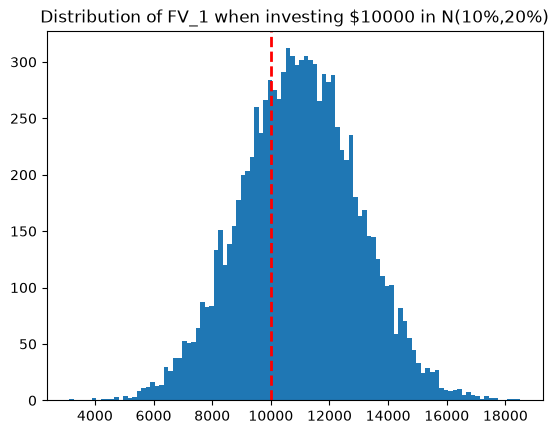

In [17]:
plt.hist(fv, bins=100)
plt.title('Distribution of FV_1 when investing $10000 in N(10%,20%)')
plt.axvline(x=10000, color="red", linestyle="--", linewidth=2)  # positive 1-year net return to right of this line
plt.show()

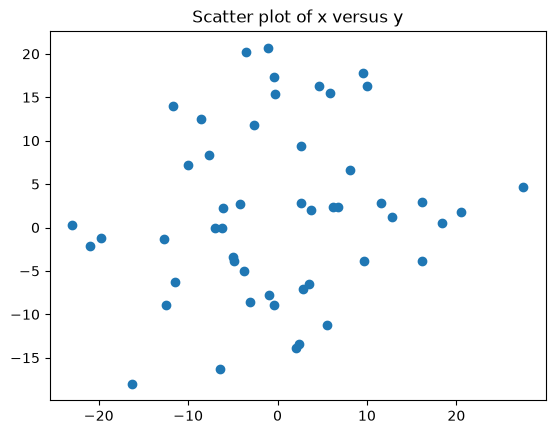

In [18]:
x = [ random.gauss(0,10)  for num in range(50) ]
y = [ random.gauss(0,10)  for num in range(50) ]
plt.scatter(x,y)
plt.title('Scatter plot of x versus y')
plt.show()